# subset_anndata_adipocytes_2k

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.io
import matplotlib.pyplot as plt
import os
import anndata 
import gc
from scipy.sparse import csr_matrix

seed=42
np.random.seed(seed)


main_path = "/rds/general/user/ap5625/home/"

input_path = "/rds/general/user/ap5625/projects/lms-scott-raw/live/T2D_REM/Phase_2/objects"

output_path = "/rds/general/user/ap5625/projects/lms-scott-raw/live/Ada/perturbation_modeling"

In [2]:
adata = sc.read_h5ad(input_path + "/Adipocytes_annotated_step2.h5ad")

In [3]:
gc.collect()
print(adata)

AnnData object with n_obs × n_vars = 155923 × 38606
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'barcodes', 'condition', 'remission', 't2d_batch', 'n_genes', 'count_keep', 'mt_keep', 'rb_keep', 'doublet_keep', 'study', 'pooled_donors', 'SeqID', 'cellID', 'Donor', 'sample', 'Chemistry', 'pool_barcodes', 'dataset', 'BMI', 'sex', 'mt.percent', 'ribo.percent', 'emont_cell_type', 'emont_cell_type2', 'cell_type_level1', 'cell_type_level2', 'cell_state', 'subUMAP1_v1', 'subUMAP2_v1', 'subUMAP1_v2', 'subUMAP2_v2', 'New_donor', 'new_sample', 'UMAPglobal_x', 'UMAPglobal_y', 'orig_barcodes', 'miranda_barcodes', 'leiden_0.1', 'leiden_0.15', 'leiden_0.25', 'leiden_

# 2 stage unagi 


In [6]:
# subset to obese and WL only
adata_2stage = adata[adata.obs['condition'].isin(['baseline', 'weightloss'])].copy()
print(adata_2stage.obs['condition'].value_counts())

condition
weightloss    91273
baseline      56955
Name: count, dtype: int64


In [7]:

cell_idx = np.random.choice(adata_2stage.n_obs, size=2000, replace=False)

gene_idx = np.random.choice(adata_2stage.n_vars, size=2000, replace=False)



adata_sub_unagi_2stage = adata_2stage[cell_idx, :][:, gene_idx].copy()

print(adata_sub_unagi_2stage.obs['condition'].value_counts())


adata_sub_unagi_2stage.write(output_path + "/unagiv3_adipocytes_subset_2k_ob_wl.h5ad")

condition
weightloss    1199
baseline       801
Name: count, dtype: int64


### NOT BALANCED - should i use the paired design so that (60/40 data split weight loss vs baseline)
- for now no, i kept it as it is 

# lean and obese

In [8]:
groups = []
for condition in ['Lean', 'baseline']:
    subset = adata[adata.obs['condition'] == condition].copy()
    sc.pp.subsample(subset, n_obs=min(1000, subset.n_obs), random_state=42)
    groups.append(subset)

adata_balanced_leanobese = groups[0].concatenate(groups[1:])

/var/tmp/pbs.2945708.pbs-7/ipykernel_2171283/823181105.py:7: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_balanced_leanobese = groups[0].concatenate(groups[1:])


In [9]:
print(adata_balanced_leanobese.obs['condition'].value_counts())
print(f"Total cells: {adata_balanced_leanobese.n_obs}")

condition
Lean        1000
baseline    1000
Name: count, dtype: int64
Total cells: 2000


In [10]:
adata_balanced_leanobese.write(output_path + "/unagiv2_adipocytes_subset_2k_lean_obese.h5ad")

# all three conditions, balance counts - for unagi (this was actually my first version / run)

In [4]:
adata.obs['condition'].value_counts()

condition
weightloss    91273
baseline      56955
Lean           7695
Name: count, dtype: int64

In [14]:
groups = []
for condition in ['Lean', 'baseline', 'weightloss']:
    subset = adata[adata.obs['condition'] == condition].copy()
    sc.pp.subsample(subset, n_obs=min(667, subset.n_obs), random_state=42)
    groups.append(subset)

adata_balanced = groups[0].concatenate(groups[1:])
print(adata_balanced.obs['condition'].value_counts())
print(f"Total cells: {adata_balanced.n_obs}")

/var/tmp/pbs.2909257.pbs-7/ipykernel_871104/670624866.py:7: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_balanced = groups[0].concatenate(groups[1:])


condition
Lean          667
baseline      667
weightloss    667
Name: count, dtype: int64
Total cells: 2001


In [15]:
adata_balanced.write(output_path + "/UNAGI_adipocytes_balanced_2k.h5ad")

In [4]:
# remove genes that do not have gene symbols 

mask = ~adata.var_names.str.startswith('ENSG')
adata = adata[:, mask].copy()

print(f"Genes remaining after filtering: {adata.n_vars}")

Genes remaining after filtering: 25644


In [5]:
cell_idx = np.random.choice(adata.n_obs, size=2000, replace=False)

gene_idx = np.random.choice(adata.n_vars, size=2000, replace=False)



In [6]:
adata_sub = adata[cell_idx, :][:, gene_idx].copy()

In [27]:
print(adata_sub)

AnnData object with n_obs × n_vars = 2000 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'barcodes', 'condition', 'remission', 't2d_batch', 'n_genes', 'count_keep', 'mt_keep', 'rb_keep', 'doublet_keep', 'study', 'pooled_donors', 'SeqID', 'cellID', 'Donor', 'sample', 'Chemistry', 'pool_barcodes', 'dataset', 'BMI', 'sex', 'mt.percent', 'ribo.percent', 'emont_cell_type', 'emont_cell_type2', 'cell_type_level1', 'cell_type_level2', 'cell_state', 'subUMAP1_v1', 'subUMAP2_v1', 'subUMAP1_v2', 'subUMAP2_v2', 'New_donor', 'new_sample', 'UMAPglobal_x', 'UMAPglobal_y', 'orig_barcodes', 'miranda_barcodes', 'leiden_0.1', 'leiden_0.15', 'leiden_0.25', 'leiden_0.5

In [7]:
print(adata.var_names.duplicated().sum())

0


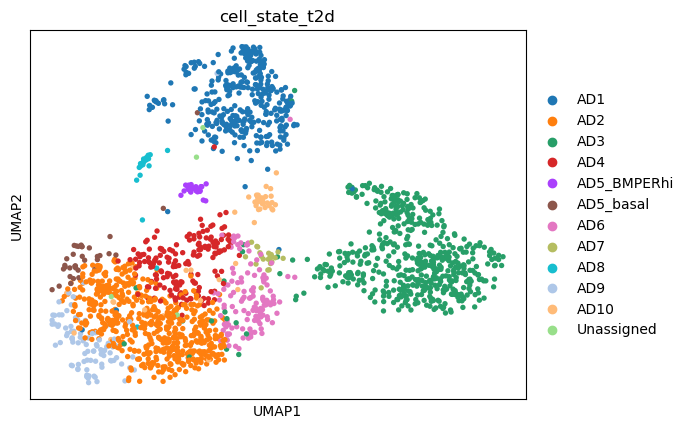

In [28]:
sc.pl.umap(adata_sub, color=["cell_state_t2d"])

In [29]:
adata_sub.write(output_path + "/adipocytes_subset_2k.h5ad")

In [30]:
cell_counts = adata_sub.obs.groupby("study").size()
print(cell_counts)

study
T2D    1673
WL      327
dtype: int64


/var/tmp/pbs.2900561.pbs-7/ipykernel_606336/2585725616.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = adata_sub.obs.groupby("study").size()


In [13]:
adata_sub.obs['condition'].value_counts()

condition
weightloss    1110
baseline       792
Lean            98
Name: count, dtype: int64

In [14]:
adata.obs['condition'].value_counts()

condition
weightloss    91273
baseline      56955
Lean           7695
Name: count, dtype: int64